In [1]:
from common.paths import get_sber_gitignore_data_dpath
from common.logger import JUPYTER_LOGGER as logger

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import catboost
import lightgbm
import xgboost
import umap
import hdbscan

import os

In [2]:
features_dpath = get_sber_gitignore_data_dpath() / "output"
features_fpaths: list = sorted(features_dpath.glob("*.csv"))
all_features = []
for fpath in features_fpaths:
    df = pd.read_csv(fpath)
    all_features.append(df)
features_df = pd.concat(all_features, ignore_index=True)
logger.info(f"Размер итогового датафрейма признаков: {features_df.shape}")

2026-03-30 22:44:29,641 - jupyter-notebooks - INFO - [JUPYTER 📓] Размер итогового датафрейма признаков: (460, 1620)


In [3]:
import warnings
warnings.filterwarnings("ignore")

string_columns = features_df.select_dtypes(include=["object"]).columns
logger.info(f"Столбцы с типом 'object': {string_columns.tolist()}")
number_columns = features_df.select_dtypes(include=[np.number]).columns
logger.info(f"Столбцы с числовыми типами: {number_columns.tolist()[:10]}... (всего {len(number_columns)})")

2026-03-30 22:44:29,674 - jupyter-notebooks - INFO - [JUPYTER 📓] Столбцы с типом 'object': ['query', 'ground_truth', 'model_answer']
2026-03-30 22:44:29,674 - jupyter-notebooks - INFO - [JUPYTER 📓] Столбцы с числовыми типами: ['sample_id', 'temperature', 'hallucination_score', 'is_hallucination', 'feature_0', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5']... (всего 1617)


In [4]:
# Стандартные текстовые признаки
features_df["query_length"] = features_df["query"].apply(lambda x: len(str(x).split()))
features_df["answer_length"] = features_df["ground_truth"].apply(lambda x: len(str(x).split()))
features_df["model_answer_length"] = features_df["model_answer"].apply(lambda x: len(str(x).split()))

features_df["query_answer_length_diff"] = features_df["query_length"] - features_df["answer_length"]
features_df["answer_model_answer_length_diff"] = features_df["answer_length"] - features_df["model_answer_length"]
features_df["query_model_answer_length_diff"] = features_df["query_length"] - features_df["model_answer_length"]

str_stats_columns = [
    "query_length",
    "answer_length",
    "model_answer_length",
    "query_answer_length_diff",
    "answer_model_answer_length_diff",
    "query_model_answer_length_diff",
]

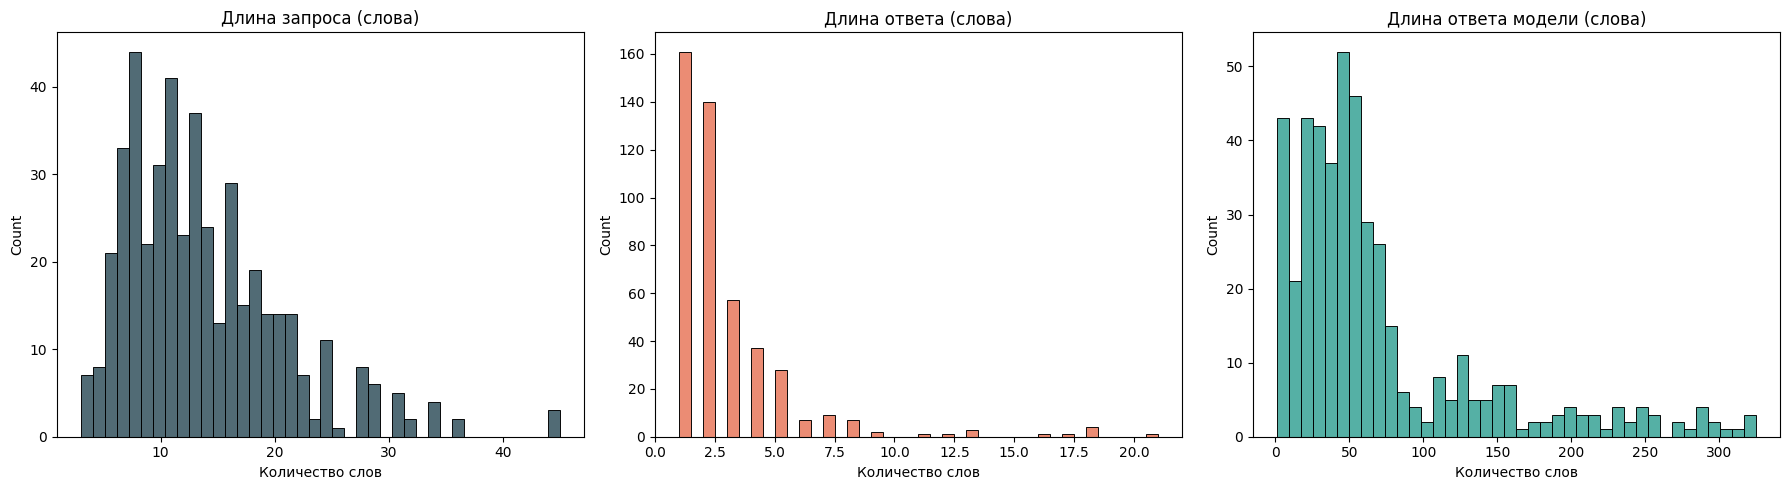

In [5]:
# Визуализация распределения текстовых признаков
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
sns.histplot(features_df["query_length"], bins=40, color="#264653", alpha=0.8)
plt.title("Длина запроса (слова)")
plt.xlabel("Количество слов")
plt.subplot(1, 3, 2)
sns.histplot(features_df["answer_length"], bins=40, color="#e76f51", alpha=0.8)
plt.title("Длина ответа (слова)")
plt.xlabel("Количество слов")
plt.subplot(1, 3, 3)
sns.histplot(features_df["model_answer_length"], bins=40, color="#2a9d8f", alpha=0.8)
plt.title("Длина ответа модели (слова)")
plt.xlabel("Количество слов")
plt.tight_layout()
plt.show()

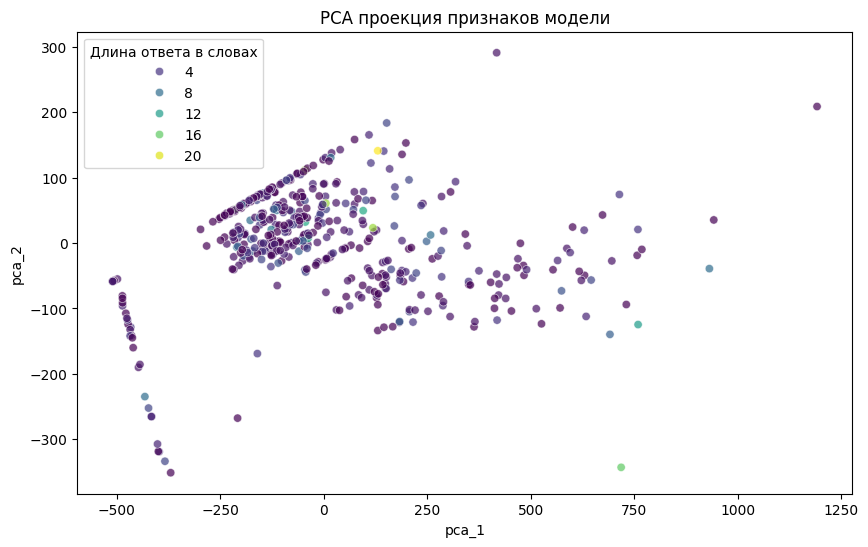

In [6]:
# PCA для хуков с модели
from sklearn.decomposition import PCA

old_pca_columns = [col for col in features_df.columns if col.startswith("pca_")]
features_df.drop(columns=old_pca_columns, inplace=True, errors="ignore")

hooks_features = [col for col in features_df.columns if col.startswith("feature")]
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(features_df[hooks_features])
pca_columns = [f"pca_{i+1}" for i in range(pca_result.shape[1])]
features_df[pca_columns] = pca_result
plt.figure(figsize=(10, 6))
sns.scatterplot(data=features_df, x="pca_1", y="pca_2", hue="answer_length", palette="viridis", alpha=0.7)
plt.title("PCA проекция признаков модели")
plt.legend(title="Длина ответа в словах")
plt.show()

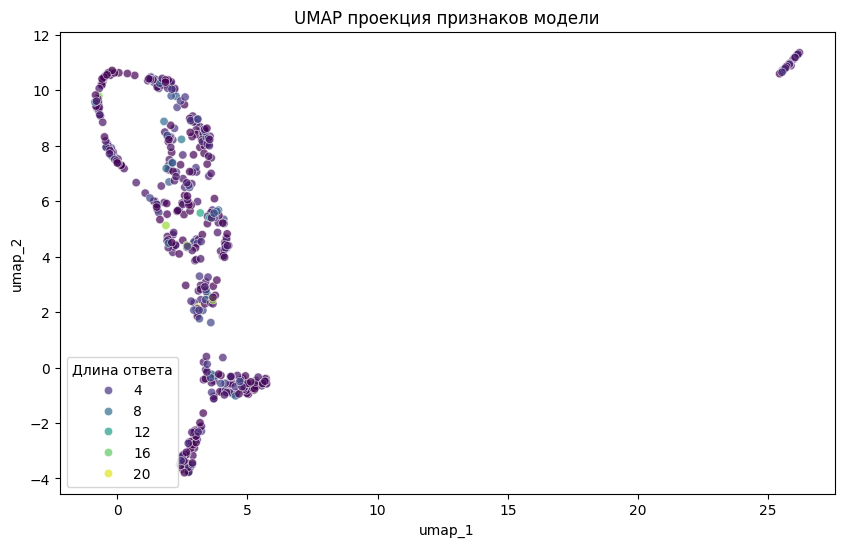

In [7]:
# UMAP для визуализации
reducer = umap.UMAP(n_components=2, random_state=42)
umap_result = reducer.fit_transform(features_df[hooks_features])
features_df["umap_1"] = umap_result[:, 0]
features_df["umap_2"] = umap_result[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=features_df, x="umap_1", y="umap_2", hue="answer_length", palette="viridis", alpha=0.7)
plt.title("UMAP проекция признаков модели")
plt.legend(title="Длина ответа")
plt.show()

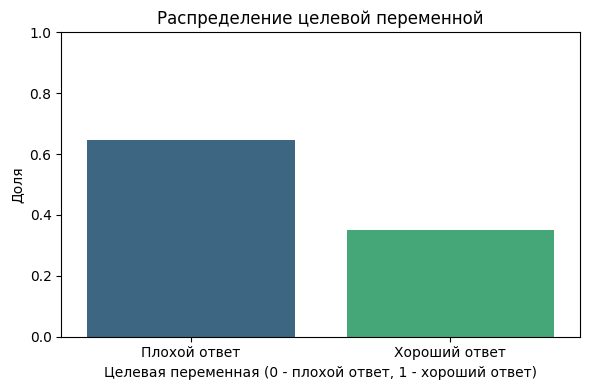

In [12]:
from rapidfuzz import fuzz

def make_target(row, fuzz_ratio_threshold=80):
    if pd.isna(row["ground_truth"]) or pd.isna(row["model_answer"]):
        return 0
    ratio = fuzz.ratio(str(row["ground_truth"]), str(row["model_answer"]))
    return int(ratio >= fuzz_ratio_threshold)

def train_test_split(X, y, test_size=0.2, random_state=42, stratify=True):
    np.random.seed(random_state)
    if stratify:
        unique_classes, class_counts = np.unique(y, return_counts=True)
        class_indices = {cls: np.where(y == cls)[0] for cls in unique_classes}
        train_indices, test_indices = [], []
        for cls in unique_classes:
            indices = class_indices[cls]
            np.random.shuffle(indices)
            split_point = int(len(indices) * (1 - test_size))
            train_indices.extend(indices[:split_point])
            test_indices.extend(indices[split_point:])
    else:
        indices = np.arange(len(y))
        np.random.shuffle(indices)
        split_point = int(len(y) * (1 - test_size))
        train_indices = indices[:split_point]
        test_indices = indices[split_point:]
    return X.iloc[train_indices], X.iloc[test_indices], y.iloc[train_indices], y.iloc[test_indices]

test_ratio = 10
X_cols = number_columns.tolist() + str_stats_columns

old_pca_columns = [col for col in features_df.columns if col.startswith("pca_")]
features_df.drop(columns=old_pca_columns, inplace=True, errors="ignore")

pca = PCA(n_components=32, random_state=42)
pca_result = pca.fit_transform(features_df[hooks_features])
pca_columns = [f"pca_{i+1}" for i in range(pca_result.shape[1])]
features_df[pca_columns] = pca_result
X_cols += pca_columns

X = features_df[X_cols]
y = features_df.apply(lambda row: make_target(row, fuzz_ratio_threshold=test_ratio), axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

target_dist = y.value_counts(normalize=True)
plt.figure(figsize=(6, 4))
sns.barplot(x=target_dist.index, y=target_dist.values, palette="viridis")
plt.title("Распределение целевой переменной")
plt.xlabel("Целевая переменная (0 - плохой ответ, 1 - хороший ответ)")
plt.ylabel("Доля")
plt.xticks([0, 1], ["Плохой ответ", "Хороший ответ"])
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [8]:
%time
import optuna

# catboost для оценки важности признаков
target_cols = number_columns.tolist() + str_stats_columns

def objective(trial):
    params_catboost = {
        "iterations": trial.suggest_int("iterations", 100, 1000),
        "depth": trial.suggest_int("depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "random_seed": 42,
        "verbose": True,
    }

    target_fuzz_threshold = trial.suggest_int("fuzz_ratio_threshold", 50, 90)
    logger.info(f"Текущие параметры: {params_catboost}, fuzz_ratio_threshold: {target_fuzz_threshold}")

    features_df["target"] = features_df.apply(lambda row: make_target(row, target_fuzz_threshold), axis=1)

    # pca
    pca = PCA(n_components=32, random_state=42)
    pca_result = pca.fit_transform(features_df[hooks_features])

    # delete old pca columns
    old_pca_columns = [col for col in features_df.columns if col.startswith("pca_")]
    features_df.drop(columns=old_pca_columns, inplace=True, errors="ignore")

    pca_columns = [f"pca_{i+1}" for i in range(pca_result.shape[1])]
    features_df[pca_columns] = pca_result

    X = features_df[target_cols]
    y = features_df["target"]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = catboost.CatBoostClassifier(**params_catboost, eval_metric="AUC")
    model.fit(X_train, y_train, eval_set=(X_test, y_test), early_stopping_rounds=50, verbose=False)
    return model.get_best_score()["validation"]["AUC"]

study = optuna.create_study(
    study_name="catboost_feature_importance",
    direction="maximize")
study.optimize(objective, n_trials=20, show_progress_bar=True, gc_after_trial=True)
logger.info(f"Лучшие параметры: {study.best_params}")
logger.info(f"Лучшее AUC: {study.best_value:.4f}")

CPU times: total: 0 ns
Wall time: 0 ns


[I 2026-03-30 22:45:34,410] A new study created in memory with name: catboost_feature_importance


  0%|          | 0/20 [00:00<?, ?it/s]

2026-03-30 22:45:34,410 - jupyter-notebooks - INFO - [JUPYTER 📓] Текущие параметры: {'iterations': 803, 'depth': 3, 'learning_rate': 0.29648369106793376, 'random_seed': 42, 'verbose': True}, fuzz_ratio_threshold: 81


[I 2026-03-30 22:45:36,866] Trial 0 finished with value: 0.6739130434782609 and parameters: {'iterations': 803, 'depth': 3, 'learning_rate': 0.29648369106793376, 'fuzz_ratio_threshold': 81}. Best is trial 0 with value: 0.6739130434782609.


2026-03-30 22:45:37,132 - jupyter-notebooks - INFO - [JUPYTER 📓] Текущие параметры: {'iterations': 785, 'depth': 8, 'learning_rate': 0.13292610655614928, 'random_seed': 42, 'verbose': True}, fuzz_ratio_threshold: 88


[W 2026-03-30 22:45:38,072] Trial 1 failed with parameters: {'iterations': 785, 'depth': 8, 'learning_rate': 0.13292610655614928, 'fuzz_ratio_threshold': 88} because of the following error: CatBoostError('catboost/private/libs/target/target_converter.cpp:404: Target contains only one unique value').
Traceback (most recent call last):
  File "C:\Users\User\anaconda3\envs\hack-mfti\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\User\AppData\Local\Temp\ipykernel_7632\1884337251.py", line 64, in objective
    model.fit(X_train, y_train, eval_set=(X_test, y_test), early_stopping_rounds=50, verbose=False)
  File "C:\Users\User\anaconda3\envs\hack-mfti\Lib\site-packages\catboost\core.py", line 5547, in fit
    self._fit(X, y, cat_features, text_features, embedding_features, None, graph, sample_weight, None, None, None, None, baseline, use_best_model,
  File "C:\Users\User\anaconda3\envs

CatBoostError: catboost/private/libs/target/target_converter.cpp:404: Target contains only one unique value

In [ ]:
best_params = study.best_params
best_fuzz_threshold = best_params.pop("fuzz_ratio_threshold")
features_df["target"] = features_df.apply(lambda row: make_target(row, best_fuzz_threshold), axis=1)

target_dist = features_df["target"].value_counts(normalize=True)
plt.figure(figsize=(6, 4))
sns.barplot(x=target_dist.index, y=target_dist.values, palette="viridis")
plt.title("Распределение целевой переменной")
plt.xlabel("Целевая переменная (0 - плохой ответ, 1 - хороший ответ)")
plt.ylabel("Доля")
plt.xticks([0, 1], ["Плохой ответ", "Хороший ответ"])
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [ ]:
pca = PCA(n_components=32, random_state=42)
pca_result = pca.fit_transform(features_df[hooks_features])

old_pca_columns = [col for col in features_df.columns if col.startswith("pca_")]
features_df.drop(columns=old_pca_columns, inplace=True, errors="ignore")

pca_columns = [f"pca_{i+1}" for i in range(pca_result.shape[1])]
features_df[pca_columns] = pca_result

X = features_df[target_cols]
y = features_df["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

final_model = catboost.CatBoostClassifier(**best_params, eval_metric="AUC")
final_model.fit(X_train, y_train, eval_set=(X_test, y_test), early_stopping_rounds=50, verbose=False)
feature_importances = final_model.get_feature_importance()
feature_names = X.columns.tolist()
feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": feature_importances
}).sort_values(by="importance", ascending=False)
plt.figure(figsize=(12, 8))
sns.barplot(data=feature_importance_df.head(20), x="importance", y="feature", palette="viridis")
plt.title("Топ-20 важных признаков по CatBoost")
plt.xlabel("Важность")
plt.ylabel("Признак")
plt.tight_layout()
plt.show()